# Stage 7 Homework — Outliers + Risk Assumptions

In this assignment I implement reusable outlier detection/handling functions, run a simple
sensitivity analysis on a synthetic daily-return series, and document the assumptions and risks
behind each choice.

**Chain:** the lecture covered detection (IQR, Z-score), handling (remove / winsorize), and
sensitivity testing. Here I adapt those methods to a generated dataset and quantify how each
choice changes summary statistics and a simple linear model.

## Setup — Generate the Dataset

The next two cells set up the project. The first is a read-only check that reports where files
live and whether `src/outliers.py` exists (it fails until the module is written). The second
generates the sample CSV under `data/raw/` and saves it — no dataset is handed out for this
assignment.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install matplotlib

In [2]:
# --- files this notebook needs (run me first - I only report, I change nothing) ---
from pathlib import Path
import sys

HOMEWORK_DIR = Path.cwd()
ROOT = HOMEWORK_DIR

DATA_RAW = ROOT / 'data' / 'raw'
DATA_PROCESSED = ROOT / 'data' / 'processed'
SRC_DIR = ROOT / 'src'

DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print('Homework directory:', HOMEWORK_DIR)
print('Raw data directory:', DATA_RAW)
print('Processed data directory:', DATA_PROCESSED)
print('Source directory:', SRC_DIR)

CHECKS = [
    ('src/outliers.py', 'NEEDED', 'YOU write this in the homework - the import fails until you do'),
]

print(f'Looking in: {ROOT}\n')
missing = 0
for rel, kind, note in CHECKS:
    here = (ROOT / rel).exists()
    if not here and kind == 'NEEDED':
        missing += 1
    print(f"  [{'OK ' if here else 'MISS'}]  {kind:<8}  {rel:<34}  {note}")

if missing:
    print(f'\n{missing} needed file(s) missing. Put them at the paths above, relative to:\n  {ROOT}')
else:
    print('\nAll needed files present.')

Homework directory: /Users/juan/Desktop/nyu bootcamp/bootcamp_henry_dong/homework/homework07
Raw data directory: /Users/juan/Desktop/nyu bootcamp/bootcamp_henry_dong/homework/homework07/data/raw
Processed data directory: /Users/juan/Desktop/nyu bootcamp/bootcamp_henry_dong/homework/homework07/data/processed
Source directory: /Users/juan/Desktop/nyu bootcamp/bootcamp_henry_dong/homework/homework07/src
Looking in: /Users/juan/Desktop/nyu bootcamp/bootcamp_henry_dong/homework/homework07

  [OK ]  NEEDED    src/outliers.py                     YOU write this in the homework - the import fails until you do

All needed files present.


In [3]:
import os
import numpy as np
import pandas as pd

np.random.seed(17)

# Business-day dates
dates = pd.date_range(start='2022-01-03', end='2022-06-10', freq='B')

# Column 1: daily_return ~ N(0, 0.01), slightly lower before May
returns = np.random.normal(0, 0.01, size=len(dates))
mask_pre_may = dates < '2022-05-01'
returns[mask_pre_may] -= 0.0015

# Inject five large 'shock' values in May (the outliers we will study)
shock_values = {
    '2022-05-02': 0.1748425237194541,
    '2022-05-03': -0.16825801732486943,
    '2022-05-06': -0.19667220757153227,
    '2022-05-09': 0.21240223590614747,
    '2022-05-12': -0.178729287231294,
}
for d, v in shock_values.items():
    idx = np.where(dates == pd.to_datetime(d))[0][0]
    returns[idx] = v

# Column 2: daily_return_2, correlated with daily_return + small noise
daily_return_2 = returns * 0.6 + np.random.normal(0, 0.005, size=len(dates))

df = pd.DataFrame({
    'date': dates,
    'daily_return': returns,
    'daily_return_2': daily_return_2,
})

# Save to CSV in raw data folder (the filename is written exactly once, here)
csv_path = DATA_RAW / 'outliers_homework.csv'
if not os.path.exists(csv_path):
    df.to_csv(csv_path, index=False)
    print(f'Synthetic dataset with two columns created and saved to {csv_path}')
else:
    print(f'File already exists at {csv_path}. Skipping CSV creation to avoid overwrite.')

Synthetic dataset with two columns created and saved to /Users/juan/Desktop/nyu bootcamp/bootcamp_henry_dong/homework/homework07/data/raw/outliers_homework.csv


## Load Data

In [4]:
data_path = Path(csv_path)  # the SAME variable the Setup cell saved to
if data_path.exists():
    df = pd.read_csv(data_path)
else:
    # Fallback (should not happen): linear trend with a few extremes
    x = np.linspace(0, 10, 200)
    y = 2.2 * x + 1 + np.random.normal(0, 1.2, size=x.size)
    y[10] += 15; y[120] -= 13; y[160] += 18
    df = pd.DataFrame({'x': x, 'y': y})

print(df.shape)
df.head()

(115, 3)


,date,daily_return,daily_return_2
0,2022-01-03,0.001263,0.003834
1,2022-01-04,-0.020046,-0.009506
2,2022-01-05,0.004739,-0.000535
3,2022-01-06,0.009953,0.012539
4,2022-01-07,0.008872,0.009840


## Outlier Functions — Improved Implementations

The reusable functions live in `src/outliers.py` and are imported below. Relative to the
starter's sample implementations, I made these changes and documented each one:

- **Empty / non-numeric input** — every function now rejects an empty or non-numeric `Series`
  with a clear error instead of silently returning a misleading result.
- **NaN handling** — each docstring states that `NaN` is left in place and *not* flagged as an
  outlier; missingness was handled in Stage 06, so these functions deliberately do not treat
  `NaN` as an extreme value.
- **`detect_outliers_iqr`** — now validates that `k > 0`.
- **`detect_outliers_zscore`** — now validates `threshold > 0`, documents why the population
  standard deviation (`ddof=0`) is used, exposes `ddof` as a parameter, and returns an
  all-`False` mask for a constant series instead of dividing by zero.
- **`winsorize_series`** — now validates `0 <= lower < upper <= 1` (the starter did not check
  that `lower < upper`).

In [5]:
# Import the packaged functions and print their full source so the
# implementations and docstrings are visible here in the notebook.
import inspect
from src import outliers

print(inspect.getsource(outliers))

"""Reusable outlier detection and handling functions for Homework 07.

This module wraps three common, distribution-based outlier rules so they can be
reused across columns and experiments:

- ``detect_outliers_iqr``     -> IQR / Tukey's-fences rule (robust to skew)
- ``detect_outliers_zscore``  -> Z-score rule (assumes a roughly normal shape)
- ``winsorize_series``        -> clip extreme values at quantile boundaries

Every function returns a *new* object and never mutates its input, so the calls
can be chained safely. NaN handling is documented on each function: missing
values were the subject of Stage 06, so these functions deliberately leave NaN
in place and do not flag it as an outlier.
"""

import pandas as pd


def _validate_series(series):
    """Return a copy of ``series`` after checking it is a non-empty numeric Series.

    Raises
    ------
    TypeError
        If ``series`` is not a pandas Series.
    ValueError
        If ``series`` is empty or not numeric.
    """
    i

## Apply Detection and Create Outlier Flags

I apply both detectors to `daily_return` (the primary numeric column) and store boolean flags.
I use the IQR rule with the default `k=1.5` as the main treatment and the Z-score rule with
`threshold=3.0` as a cross-check, because the IQR rule is robust to the very extremes it flags.

In [6]:
target_col = 'daily_return'

df['outlier_iqr'] = outliers.detect_outliers_iqr(df[target_col], k=1.5)
df['outlier_z'] = outliers.detect_outliers_zscore(df[target_col], threshold=3.0)

print(f'rows: {len(df)}  |  IQR flags: {int(df["outlier_iqr"].sum())}  |  Z flags: {int(df["outlier_z"].sum())}')
print('\nIQR-flagged rows (dates):')
print(df.loc[df['outlier_iqr'], ['date', target_col]].to_string(index=False))

rows: 115  |  IQR flags: 9  |  Z flags: 5

IQR-flagged rows (dates):
      date  daily_return
2022-03-01      0.031952
2022-03-31     -0.031101
2022-05-02      0.174843
2022-05-03     -0.168258
2022-05-04     -0.033999
2022-05-06     -0.196672
2022-05-09      0.212402
2022-05-11      0.028711
2022-05-12     -0.178729


### Visual Checks (boxplot / histogram)

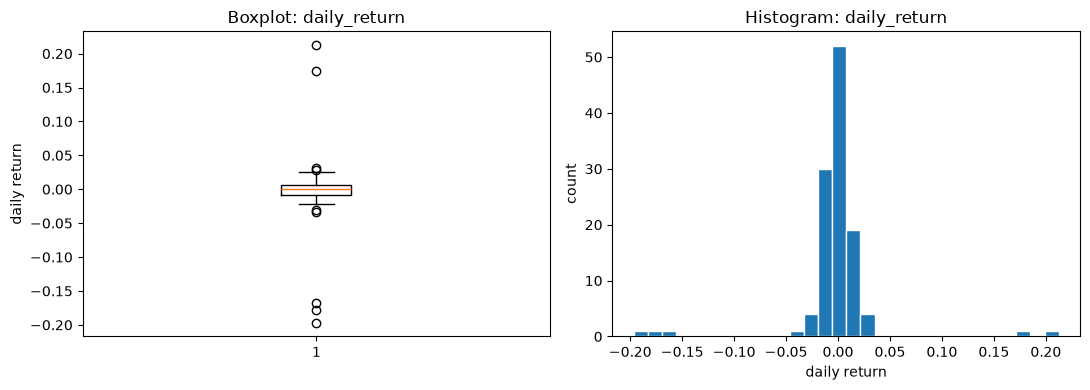

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].boxplot(df[target_col], whis=1.5)
axes[0].set_title(f'Boxplot: {target_col}')
axes[0].set_ylabel('daily return')

axes[1].hist(df[target_col], bins=30, edgecolor='white')
axes[1].set_title(f'Histogram: {target_col}')
axes[1].set_xlabel('daily return')
axes[1].set_ylabel('count')

fig.tight_layout()
plt.show()

## Sensitivity Analysis

I compare three treatments of `daily_return`:

1. **all** — every observation kept, outliers included.
2. **filtered_iqr** — rows flagged by the IQR rule removed.
3. **winsorized** — extreme values capped at the 5th/95th percentile (no rows deleted).

I report summary statistics (mean / median / std) and, because the dataset has two correlated
numeric columns, a simple least-squares regression of `daily_return_2` on `daily_return`. Since
`daily_return_2` was generated as `0.6 * daily_return + noise`, the *true* slope is about 0.6 —
a target to judge each treatment against.

In [8]:
# --- Summary statistics: all vs filtered vs winsorized ---
def _summary(s):
    return pd.Series({
        'mean': s.mean(),
        'median': s.median(),
        'std': s.std(ddof=1),
    })

wins_x = outliers.winsorize_series(df[target_col], lower=0.05, upper=0.95)

summary_comparison = pd.DataFrame({
    'all': _summary(df[target_col]),
    'filtered_iqr': _summary(df.loc[~df['outlier_iqr'], target_col]),
    'winsorized': _summary(wins_x),
})

summary_comparison.round(5)

,all,filtered_iqr,winsorized
mean,-0.00143,-0.00004,-0.00025
median,-0.00019,-0.00010,-0.00019
std,0.04058,0.00944,0.01062


In [9]:
# --- Regression: daily_return_2 ~ daily_return, for each treatment ---
def ols_summary(x, y):
    """Fit y ~ 1 + x by least squares; return (intercept, slope, r2, mae).

    This reproduces sklearn's LinearRegression (it solves the same normal
    equations with np.linalg.lstsq) so the notebook has no extra dependency.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    X = np.column_stack([np.ones(x.size), x])
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    intercept, slope = coef[0], coef[1]
    y_pred = intercept + slope * x
    ss_res = float(np.sum((y - y_pred) ** 2))
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else float('nan')
    mae = float(np.mean(np.abs(y - y_pred)))
    return intercept, slope, r2, mae

resp_col = 'daily_return_2'
mask_iqr = df['outlier_iqr']

# For the winsorized treatment, cap BOTH columns so the predictor and response
# stay aligned; winsorizing only the predictor would decouple the pair.
wins_y = outliers.winsorize_series(df[resp_col], lower=0.05, upper=0.95)

treatments = {
    'all': (df[target_col].to_numpy(), df[resp_col].to_numpy()),
    'filtered_iqr': (
        df.loc[~mask_iqr, target_col].to_numpy(),
        df.loc[~mask_iqr, resp_col].to_numpy(),
    ),
    'winsorized': (wins_x.to_numpy(), wins_y.to_numpy()),
}

rows = {}
for name, (x, y) in treatments.items():
    intercept, slope, r2, mae = ols_summary(x, y)
    rows[name] = {'slope': slope, 'intercept': intercept, 'r2': r2, 'mae': mae}

regression_comparison = pd.DataFrame(rows).T
regression_comparison.index.name = 'treatment'
regression_comparison.round(4)

,slope,intercept,r2,mae
treatment,,,,
all,0.6059,0.0002,0.9619,0.0040
filtered_iqr,0.5897,-0.0000,0.5736,0.0039
winsorized,0.6497,-0.0000,0.6894,0.0037


### Plots

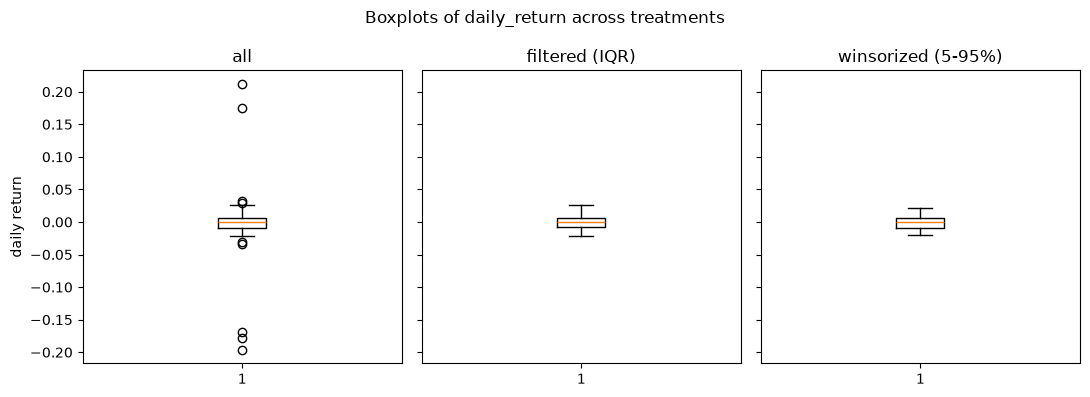

In [10]:
# Plot 1: boxplots for the three treatments (before / after)
fig, axes = plt.subplots(1, 3, figsize=(11, 4), sharey=True)

axes[0].boxplot(df[target_col], whis=1.5)
axes[0].set_title('all')
axes[0].set_ylabel('daily return')

axes[1].boxplot(df.loc[~mask_iqr, target_col], whis=1.5)
axes[1].set_title('filtered (IQR)')

axes[2].boxplot(wins_x, whis=1.5)
axes[2].set_title('winsorized (5-95%)')

fig.suptitle(f'Boxplots of {target_col} across treatments')
fig.tight_layout()
plt.show()

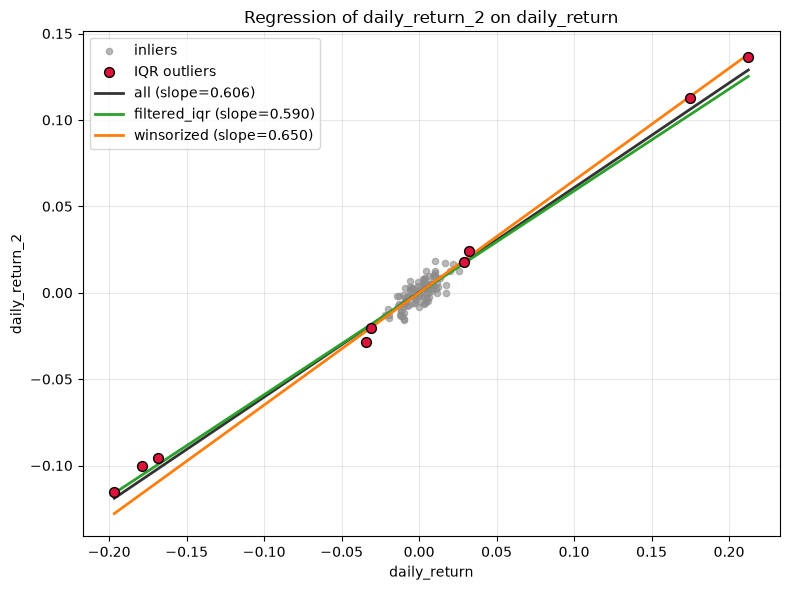

In [11]:
# Plot 2: scatter with fitted lines for each treatment, outliers highlighted
fig, ax = plt.subplots(figsize=(8, 6))

x_all = df[target_col].to_numpy()
y_all = df[resp_col].to_numpy()

ax.scatter(x_all[~mask_iqr], y_all[~mask_iqr], s=20, alpha=0.6, color='0.55', label='inliers')
ax.scatter(x_all[mask_iqr], y_all[mask_iqr], s=50, edgecolor='black', facecolor='crimson',
           zorder=3, label='IQR outliers')

grid = np.linspace(x_all.min(), x_all.max(), 100)
for name, color in [('all', '0.2'), ('filtered_iqr', 'tab:green'), ('winsorized', 'tab:orange')]:
    x, y = treatments[name]
    intercept, slope, _, _ = ols_summary(x, y)
    ax.plot(grid, intercept + slope * grid, color=color, lw=2, label=f'{name} (slope={slope:.3f})')

ax.set_xlabel(target_col)
ax.set_ylabel(resp_col)
ax.set_title('Regression of daily_return_2 on daily_return')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Reflection

**Methods and thresholds chosen, and why.** I used the IQR rule with the default `k=1.5` as my
primary treatment and the Z-score rule with `threshold=3.0` as a cross-check. I chose IQR as the
main method because it is built from quartiles, which are robust to the very extremes it is
trying to flag, so a handful of huge shocks cannot hide the more moderate outliers. The Z-score
is the natural complement, but it is sensitive to heavy tails — and here it demonstrates that
sensitivity.

**Assumptions behind the choices.** (1) The IQR rule assumes the bulk of the data is well
summarized by Q1/Q3 and that anything beyond `1.5 × IQR` is unusual; `k=1.5` is Tukey's
conventional "far out" fence. (2) The Z-score assumes an approximately normal distribution and
uses the population standard deviation (`ddof=0`), i.e. it treats the observed 115 rows as the
whole population rather than a sample; that denominator is itself inflated by the outliers.
(3) Winsorizing assumes extreme values are genuine but should be *capped* rather than *deleted*,
and that the 5%/95% cutoffs capture the right amount of tail (here roughly 10% of rows). For the
regression I winsorized *both* columns so the predictor and response stay aligned.

**Observed impact on results.** The five shocks are net negative, so the mean of `daily_return`
is dragged down: `-0.00143` for all data vs. `-0.00004` filtered and `-0.00025` winsorized. The
standard deviation collapses from `0.0406` to `~0.010` once the shocks are removed or capped,
while the median barely moves (`-0.00019` → `-0.00010`), confirming the median's robustness. In
the regression, all three treatments recover a slope near the true `0.6` (all `0.606`, filtered
`0.590`, winsorized `0.650`), but in-sample R² drops sharply when the outliers are removed
(`0.96` → `0.57`) because the shocks lie almost on the true line — they are informative, not
noise. MAE stays near `0.004`.

**Risks if assumptions are wrong.** The largest risk is misclassifying *genuine events* as
errors: these "outliers" are real shocks, and deleting them silently biases the analysis toward
calm periods and hides tail risk. A related risk is Z-score masking — its mean/std are inflated
by the same outliers, so it flags only 5 of the 9 points the IQR rule catches. Winsorizing
assumes we know the contamination rate; a wrong cutoff either leaves too much tail influence or
flattens real variation. Finally, in-sample R²/MAE are not comparable across subsets of different
sizes, so "R² dropped" must not be read as "the model got worse" — the known slope of 0.6 here
shows the filtered/winsorized fits are slightly *less* accurate, not more.